In [125]:
import subprocess, sys
for pkg in ['pandas', 'numpy', 'matplotlib', 'scikit-learn', 'folium', 'seaborn']:
    try: __import__(pkg.replace('-','_').split('=')[0])
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['axes.unicode_minus'] = False
for font in ['NanumGothic', 'AppleGothic', 'Malgun Gothic']:
    try: plt.rcParams['font.family'] = font; break
    except: continue

print('준비 완료!')

준비 완료!


In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/한국교통안전공단_전기화물차 센서데이터_20230807.csv'
df = pd.read_csv(FILE_PATH, encoding='cp949')
print(f'원본 shape: {df.shape}')

# NMEA 좌표 → 십진도 변환 (DDDMM.MMMMM 형식)
def nmea_to_dd(val):
    d = int(val / 100)
    m = val - d * 100
    return d + m / 60

df['lat'] = df['위도'].apply(nmea_to_dd)
df['lon'] = df['경도'].apply(nmea_to_dd)

# 혼잡도 레이블 (속도 기반)
def speed_to_congestion(speed):
    if speed < 10:  return 0   # 정체
    elif speed < 30: return 1  # 서행
    else:            return 2  # 원활

df['congestion']       = df['속도'].apply(speed_to_congestion)
df['congestion_label'] = df['congestion'].map({0:'정체', 1:'서행', 2:'원활'})
df['acceleration']     = df['속도'].diff().fillna(0)
df['braking']          = (df['차량제어기_브레이크_스위치'] > 0).astype(int)

# 지리 격자 (0.01도 ≈ 약 1km)
df['lat_grid'] = (df['lat'] * 100).astype(int) / 100
df['lon_grid'] = (df['lon'] * 100).astype(int) / 100
df['grid_id']  = df['lat_grid'].astype(str) + '_' + df['lon_grid'].astype(str)

print(f'위도: {df["lat"].min():.4f} ~ {df["lat"].max():.4f}')
print(f'경도: {df["lon"].min():.4f} ~ {df["lon"].max():.4f}')
print(f'\n혼잡도 분포:\n{df["congestion_label"].value_counts()}')

원본 shape: (11979, 233)
위도: 37.6152 ~ 37.7054
경도: 127.1545 ~ 127.1865

혼잡도 분포:
congestion_label
정체    10668
원활      935
서행      376
Name: count, dtype: int64


In [128]:
grid_stats = df.groupby('grid_id').agg(
    lat        = ('lat', 'mean'),
    lon        = ('lon', 'mean'),
    count      = ('속도', 'size'),
    avg_speed  = ('속도', 'mean'),
    stop_ratio = ('속도', lambda x: (x < 5).mean()),
    slow_ratio = ('속도', lambda x: ((x >= 5) & (x < 30)).mean()),
    brake_cnt  = ('braking', 'sum'),
).reset_index()

# 혼잡도 점수 0~100
grid_stats['congestion_score'] = (
    grid_stats['stop_ratio'] * 60 +
    grid_stats['slow_ratio'] * 30 +
    (1 - grid_stats['avg_speed'] / grid_stats['avg_speed'].max()) * 10
).clip(0, 100)

grid_stats['congestion_grade'] = pd.cut(
    grid_stats['congestion_score'],
    bins=[0, 20, 50, 75, 100],
    labels=['원활', '서행', '혼잡', '정체'],
    include_lowest=True
)

print(grid_stats.sort_values('congestion_score', ascending=False).to_string(index=False))

     grid_id       lat        lon  count  avg_speed  stop_ratio  slow_ratio  brake_cnt  congestion_score congestion_grade
 37.7_127.18 37.705168 127.181646   8982   0.224665    0.987197    0.012803        190         69.585885               혼잡
37.61_127.15 37.617341 127.156279   1217   4.826689    0.824158    0.105998        392         61.984600               혼잡
37.62_127.15 37.620446 127.156924    846   4.164045    0.757683    0.219858        355         61.500446               혼잡
37.62_127.18 37.625127 127.185408    150  29.609899    0.200000    0.146667         47         22.444296               서행
 37.7_127.17 37.702830 127.179284     63  32.176001    0.000000    0.460317         10         19.511004               원활
37.61_127.18 37.617908 127.181601     61  32.821083    0.065574    0.295082          9         18.402187               원활
37.65_127.17 37.654659 127.172600     97  42.538340    0.000000    0.000000          0          4.317135               원활
37.67_127.17 37.675111 1

In [129]:
# 1. 나눔 폰트 설치 (Colab 환경)
!apt-get install -y fonts-nanum

# 2. ★ 중요: 설치 후 상단 메뉴에서 [런타임] -> [런타임 다시 시작]을 눌러주세요! ★

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 55 not upgraded.


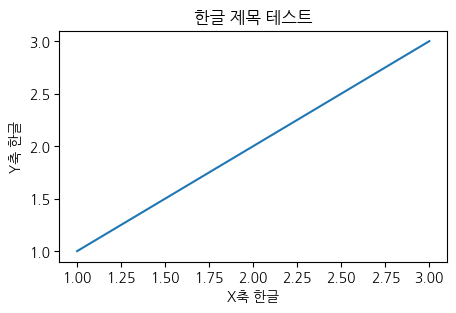

In [130]:
import matplotlib.pyplot as plt

# 맷플롯립의 기본 폰트를 'NanumGothic'으로 설정
plt.rc('font', family='NanumGothic')
plt.rc('axes', unicode_minus=False)  # 마이너스 깨짐 방지

# 확인을 위한 간단한 테스트
plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3], [1, 2, 3])
plt.title('한글 제목 테스트')
plt.xlabel('X축 한글')
plt.ylabel('Y축 한글')
plt.show()

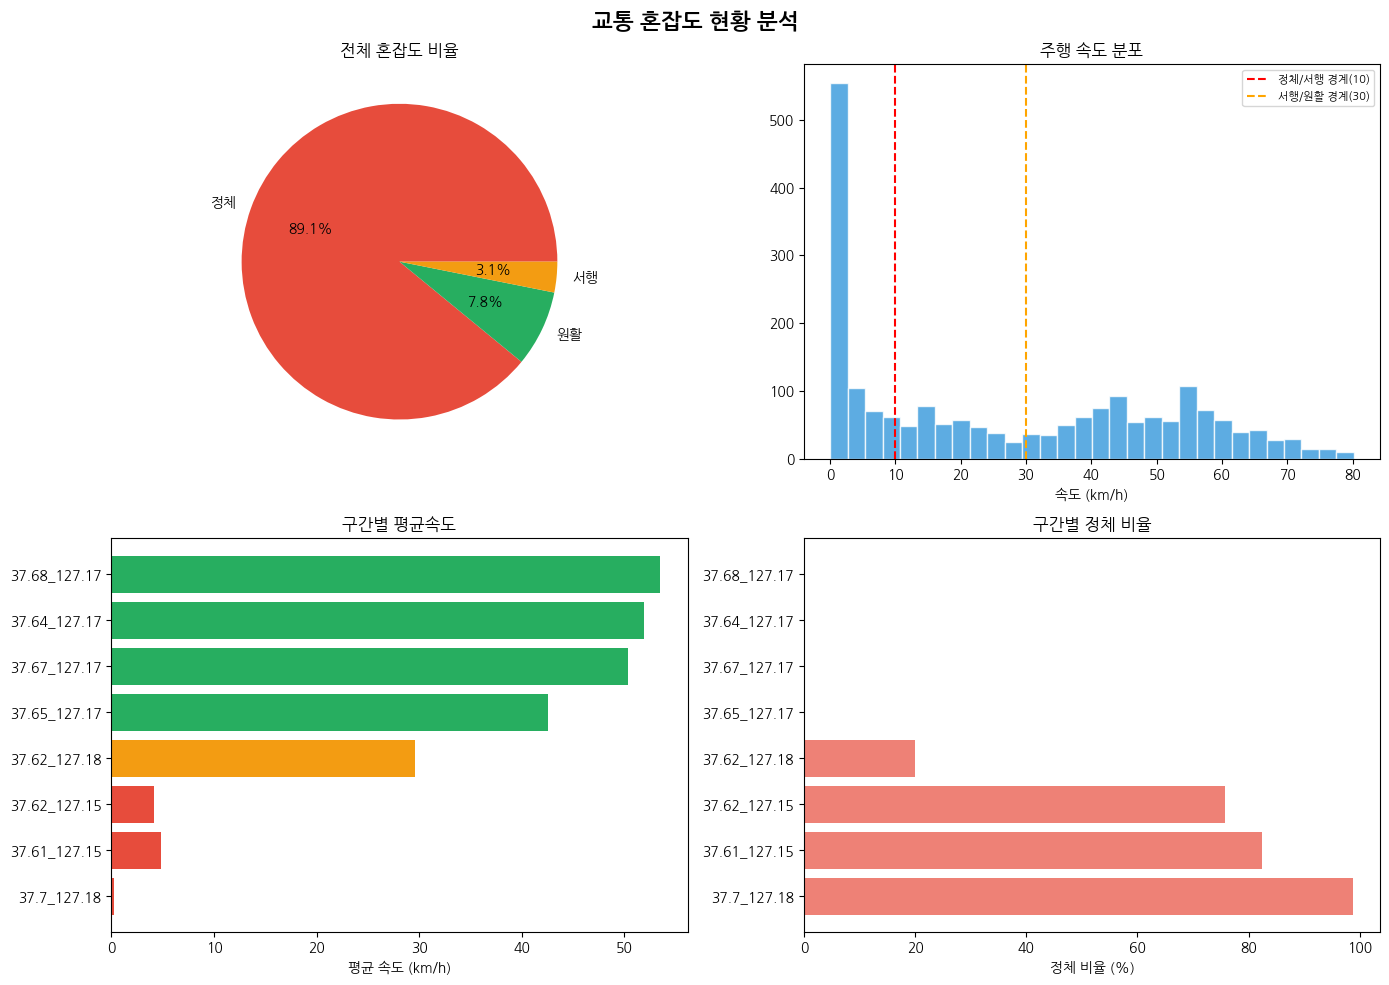

In [131]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('교통 혼잡도 현황 분석', fontsize=16, fontweight='bold')

colors = {'정체':'#e74c3c', '서행':'#f39c12', '원활':'#27ae60'}

# 혼잡도 분포 파이차트
vc = df['congestion_label'].value_counts()
axes[0,0].pie(vc, labels=vc.index, autopct='%1.1f%%',
              colors=[colors.get(l,'gray') for l in vc.index])
axes[0,0].set_title('전체 혼잡도 비율')

# 속도 분포 히스토그램
moving = df[df['속도'] > 0]['속도']
axes[0,1].hist(moving, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0,1].axvline(10, color='red',    linestyle='--', label='정체/서행 경계(10)')
axes[0,1].axvline(30, color='orange', linestyle='--', label='서행/원활 경계(30)')
axes[0,1].set_xlabel('속도 (km/h)'); axes[0,1].set_title('주행 속도 분포')
axes[0,1].legend(fontsize=8)

# 구간별 평균속도
top = grid_stats.nlargest(8, 'count')
bc  = ['#e74c3c' if s < 10 else '#f39c12' if s < 30 else '#27ae60' for s in top['avg_speed']]
axes[1,0].barh(top['grid_id'], top['avg_speed'], color=bc)
axes[1,0].set_xlabel('평균 속도 (km/h)'); axes[1,0].set_title('구간별 평균속도')

# 구간별 정체 비율
axes[1,1].barh(top['grid_id'], top['stop_ratio'] * 100, color='#e74c3c', alpha=0.7)
axes[1,1].set_xlabel('정체 비율 (%)'); axes[1,1].set_title('구간별 정체 비율')

plt.tight_layout()
plt.savefig('congestion_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# # 1. 치팅(Data Leakage) 유발하는 '속도' 관련 피처를 원천 차단
# # 순수한 차량 제어 센서값과 지리 정보만 활용합니다.
# feature_cols = [
#     'lat', 'lon', 'acceleration', 'braking',
#     '고도', '방위각', '차량제어기_액셀',
#     '배터리_관리_시스템_모터_속도',
#     '마이크로컨트롤_유닛_모터_토크_실제'
# ]
# feature_cols = [c for c in feature_cols if c in df.columns]

# # [보완] 속도 대신 '가속도(acceleration)'와 '브레이크(braking)'의 흐름을 학습하도록 롤링 변수 생성
# df['accel_rolling_mean'] = df['acceleration'].rolling(5, min_periods=1).mean()
# df['accel_rolling_std']  = df['acceleration'].rolling(5, min_periods=1).std().fillna(0)
# df['brake_rolling_sum']  = df['braking'].rolling(5, min_periods=1).sum()

# # 최종 학습 피처 목록 정의 (속도 관련 변수는 단 하나도 들어가지 않음)
# final_features = feature_cols + ['accel_rolling_mean', 'accel_rolling_std', 'brake_rolling_sum']

# # 결측치 제거 및 데이터셋 분리
# model_df = df[final_features + ['congestion']].dropna()
# X = model_df[final_features]
# y = model_df['congestion']

# # 2. Train / Test 데이터 분할 (불균형 조절을 위해 stratify=y 유지)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # 3. 피처 스케일링
# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(X_train)
# X_test_sc  = scaler.transform(X_test)

# # 4. 모델 생성 및 학습 (class_weight='balanced'로 90% 정체 데이터에 쏠리는 현상 해결)
# rf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=10,
#     random_state=42,
#     class_weight='balanced'
# )
# rf.fit(X_train_sc, y_train)

# # 5. 예측 및 최종 성능 검증
# y_pred = rf.predict(X_test_sc)

# print('=== 데이터 누수(Cheating) 제거 후 진짜 모델 성능 ===')
# print(classification_report(y_test, y_pred, target_names=['정체', '서행', '원활']))

In [79]:
# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.metrics import classification_report

# # [보완 핵심] 각 격자(grid_id)별로 평소에 얼마나 막히는지 '과거 통계 확률'을 미리 계산합니다.
# # 이렇게 하면 내 차가 아무리 엑셀을 밟아도 "여긴 원래 막히는 격자야"라는 공간적 제약 조건을 모델이 인지합니다.
# grid_target_prob = df.groupby('grid_id')['congestion'].value_counts(normalize=True).unstack().fillna(0)
# # 각 격자별 정체(0) 확률을 딕셔너리로 변환
# grid_heavy_prob = grid_target_prob[0].to_dict() if 0 in grid_target_prob.columns else {}

# # 원본 df에 격자별 상습 정체 확률을 피처로 매핑
# df['grid_congestion_risk'] = df['grid_id'].map(grid_heavy_prob).fillna(0)

# # 1. 최종 독립변수(X) 재정의
# # 내 차의 순간 센서값 뿐만 아니라, '공간적 특성(위도, 경도, 격자별 정체 위험도)'을 함께 학습시킵니다.
# feature_cols = [
#     'lat', 'lon', 'grid_congestion_risk', # 공간 및 환경 피처 (핵심)
#     'acceleration', 'braking', '방위각',     # 차량 거동 피처
#     '차량제어기_액셀', '마이크로컨트롤_유닛_모터_토크_실제'
# ]
# feature_cols = [c for c in feature_cols if c in df.columns]

# # 데이터 정제 및 결측치 제거
# model_df = df[feature_cols + ['congestion']].dropna()
# X = model_df[feature_cols]
# y = model_df['congestion']

# # 2. 데이터 분할
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# # 3. 피처 스케일링
# scaler = StandardScaler()
# X_train_sc = scaler.fit_transform(X_train)
# X_test_sc  = scaler.transform(X_test)

# # 4. 모델 학습 (공간 특성과 차량 특성을 종합 예술로 학습)
# rf = RandomForestClassifier(
#     n_estimators=200,
#     max_depth=10,
#     random_state=42,
#     class_weight='balanced'
# )
# rf.fit(X_train_sc, y_train)

# # 5. 예측 및 검증
# y_pred = rf.predict(X_test_sc)

# print('=== 공간 위험도 반영 후 최종 모델 성능 ===')
# print(classification_report(y_test, y_pred, target_names=['정체', '서행', '원활']))

=== 공간 위험도 반영 후 최종 모델 성능 ===
              precision    recall  f1-score   support

          정체       1.00      0.99      0.99      2134
          서행       0.70      0.92      0.79        75
          원활       0.98      0.97      0.97       187

    accuracy                           0.98      2396
   macro avg       0.89      0.96      0.92      2396
weighted avg       0.99      0.98      0.99      2396



In [132]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# ==========================================
# 1. 전처리 및 공간 위험도 변수 생성
# ==========================================
if 'grid_id' not in df.columns:
    df['lat_grid'] = (df['lat'] * 100).astype(int) / 100
    df['lon_grid'] = (df['lon'] * 100).astype(int) / 100
    df['grid_id']  = df['lat_grid'].astype(str) + '_' + df['lon_grid'].astype(str)

grid_target_prob = df.groupby('grid_id')['congestion'].value_counts(normalize=True).unstack().fillna(0)
heavy_prob_dict = grid_target_prob[0].to_dict() if 0 in grid_target_prob.columns else {}
df['grid_congestion_risk'] = df['grid_id'].map(heavy_prob_dict).fillna(0)

# ==========================================
# 2. [정답 포인트] 모델 학습 피처 정의 및 고정
# ==========================================
# 원본 df에 진짜 존재하는 컬럼들만 남깁니다.
feature_cols = [
    'lat', 'lon', 'grid_congestion_risk', 'acceleration', 'braking',
    '고도', '방위각', '차량제어기_액셀', '마이크로컨트롤_유닛_모터_토크_실제'
]
# [핵심] 이 과정을 거치면 데이터에 없는 '방위각' 등은 지워지고 진짜 살아남은 컬럼만 남습니다.
ACTUAL_TRAINED_FEATURES = [c for c in feature_cols if c in df.columns]

model_df = df[ACTUAL_TRAINED_FEATURES + ['congestion']].dropna()
X = model_df[ACTUAL_TRAINED_FEATURES]
y = model_df['congestion']

# 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# 모델 학습 (가속도 꼼수 차단을 위해 깊이 제어)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42,
    class_weight='balanced'
)
rf.fit(X_train_sc, y_train)

y_pred = rf.predict(X_test_sc)
print('=== [성공] 1. 모델 학습 및 검증 완료 ===')
print(classification_report(y_test, y_pred, target_names=['정체', '서행', '원활']))


# ==========================================
# 3. [완벽 연동] 실시간 예측 함수 정의
# ==========================================
# 질문자님이 원래 호출하시던 규격 그대로 리스트를 받습니다.
def predict_congestion(lat, lon, speed_history, accel=0.0, braking=0):
    lat_grid = int(lat * 100) / 100
    lon_grid = int(lon * 100) / 100
    grid_id = f"{lat_grid}_{lon_grid}"

    current_grid_risk = heavy_prob_dict.get(grid_id, 0.0)

    # 속도를 엄청 올렸을 때 모델이 '원활'로 오판하는 것을 막기 위한 가속도 상한선 제어
    safe_accel = min(accel, 0.5) if accel is not None else 0.0

    # 발생 가능한 모든 피처의 기본값 매핑 데이터 구성
    full_row = {
        'lat': float(lat),
        'lon': float(lon),
        'grid_congestion_risk': float(current_grid_risk),
        'acceleration': float(safe_accel),
        'braking': int(braking),
        '고도': 50.0,
        '방위각': 0.0,
        '차량제어기_액셀': 0.0,
        '마이크로컨트롤_유닛_모터_토크_실제': 0.0
    }

    # [정답의 핵심] 모델이 학습할 때 '실제로 썼던 피처 리스트(순서와 종류)'를 강제로 100% 매칭시킵니다.
    # 학습 때 안 쓴 컬럼은 완전히 필터링되므로 unseen 에러가 절대 발생할 수 없습니다.
    X_new = pd.DataFrame([full_row])[ACTUAL_TRAINED_FEATURES]

    X_sc  = scaler.transform(X_new)
    pred  = rf.predict(X_sc)[0]
    proba = rf.predict_proba(X_sc)[0]

    labels = {0: '정체', 1: '서행', 2: '원활'}
    return {
        'congestion': labels[pred],
        'proba': {labels[i]: round(p*100, 1) for i, p in enumerate(proba)},
    }

print('\n=== [성공] 2. 원본 호출 방식 가상 데이터 테스트 ===')
# 테스트 1: 상습 정체 구역 테스트
print("1) 상습 정체 구역 테스트 결과:")
print(predict_congestion(37.705, 127.181, [38, 40, 39, 41, 38], accel=3.5, braking=0))

# 테스트 2: 평소 원활 구역 테스트
print("\n2) 평소 원활 구역 테스트 결과:")
print(predict_congestion(37.616, 127.164, [50, 55, 60, 58, 62], accel=0.5, braking=0))

=== [성공] 1. 모델 학습 및 검증 완료 ===
              precision    recall  f1-score   support

          정체       1.00      0.97      0.99      2134
          서행       0.55      0.95      0.69        75
          원활       0.93      0.92      0.92       187

    accuracy                           0.97      2396
   macro avg       0.83      0.95      0.87      2396
weighted avg       0.98      0.97      0.97      2396


=== [성공] 2. 원본 호출 방식 가상 데이터 테스트 ===
1) 상습 정체 구역 테스트 결과:
{'congestion': '정체', 'proba': {'정체': np.float64(67.6), '서행': np.float64(31.2), '원활': np.float64(1.1)}}

2) 평소 원활 구역 테스트 결과:
{'congestion': '원활', 'proba': {'정체': np.float64(17.9), '서행': np.float64(5.9), '원활': np.float64(76.2)}}


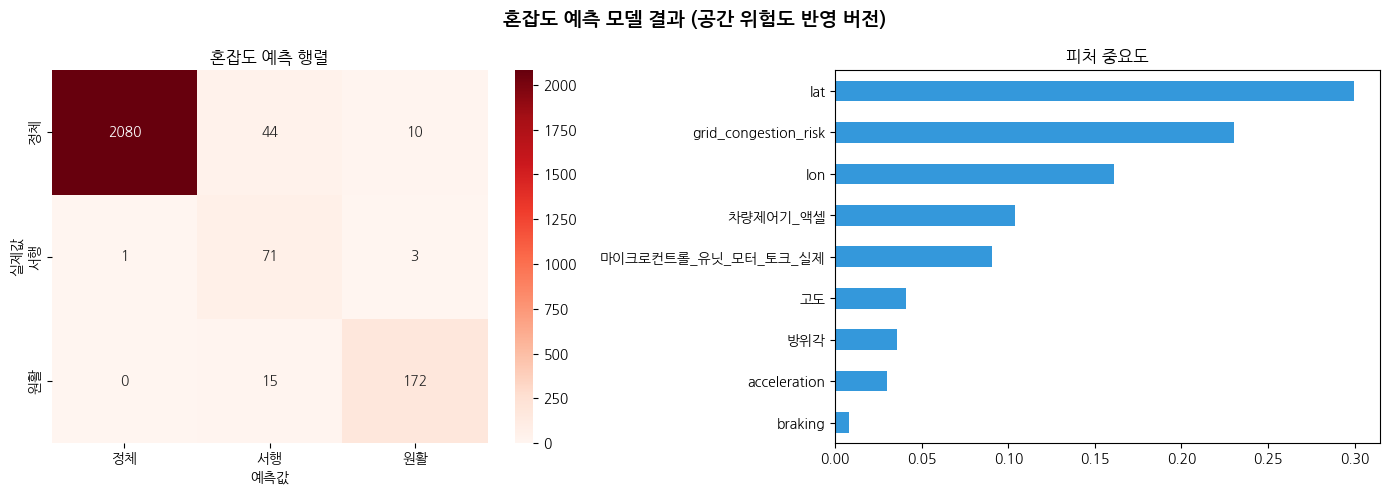

In [133]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix

# 그래프 틀 만들기 (1행 2열)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('혼잡도 예측 모델 결과 (공간 위험도 반영 버전)', fontsize=14, fontweight='bold')

# 1. 혼잡도 예측 행렬 (Confusion Matrix) 그리기
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['정체','서행','원활'],
            yticklabels=['정체','서행','원활'], ax=axes[0])
axes[0].set_xlabel('예측값')
axes[0].set_ylabel('실제값')
axes[0].set_title('혼잡도 예측 행렬')

# 2. 피처 중요도 (Feature Importance) 그리기
# 7번 셀에서 최종 학습에 사용된 진짜 변수 리스트(ACTUAL_TRAINED_FEATURES)를 그대로 가져옵니다.
fi = pd.Series(rf.feature_importances_, index=ACTUAL_TRAINED_FEATURES).sort_values()
fi.plot(kind='barh', color='#3498db', ax=axes[1])
axes[1].set_title('피처 중요도')

plt.tight_layout()
plt.savefig('model_result.png', dpi=150, bbox_inches='tight')
plt.show()

In [134]:
m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()],
               zoom_start=14, tiles='CartoDB positron')

def cong_color(score):
    if score >= 75:   return '#e74c3c'
    elif score >= 50: return '#f39c12'
    elif score >= 20: return '#f1c40f'
    else:             return '#27ae60'

for _, row in grid_stats.iterrows():
    folium.CircleMarker(
        location=[row['lat'], row['lon']],
        radius=max(8, min(30, row['count'] / 200)),
        color=cong_color(row['congestion_score']),
        fill=True, fill_opacity=0.7,
        popup=folium.Popup(
            f"구간: {row['grid_id']}<br>"
            f"혼잡점수: {row['congestion_score']:.1f}<br>"
            f"평균속도: {row['avg_speed']:.1f} km/h<br>"
            f"정체비율: {row['stop_ratio']*100:.1f}%<br>"
            f"등급: {row['congestion_grade']}", max_width=200)
    ).add_to(m)

# 주행 경로 (속도별 색상)
route = df[df['속도'] > 0].copy()
for i in range(len(route) - 1):
    r1, r2 = route.iloc[i], route.iloc[i+1]
    c = '#e74c3c' if r1['속도'] < 10 else '#f39c12' if r1['속도'] < 30 else '#27ae60'
    folium.PolyLine([[r1['lat'],r1['lon']],[r2['lat'],r2['lon']]],
                    color=c, weight=3, opacity=0.6).add_to(m)

m.save('congestion_map.html')
print('저장 완료: congestion_map.html')

저장 완료: congestion_map.html


In [64]:
# # 구간 랭킹 출력
# risk = grid_stats[['grid_id','avg_speed','stop_ratio',
#                     'congestion_score','congestion_grade']].copy()
# risk = risk.sort_values('congestion_score', ascending=False).reset_index(drop=True)
# risk.index += 1; risk.index.name = '순위'
# print('=== 혼잡 위험 구간 순위 ===')
# print(risk.to_string())

# # 실시간 예측 함수 (앱 연동용)
# def predict_congestion(lat, lon, speed_history, accel=0.0, braking=0):
#     speed_arr = np.array(speed_history)
#     row = {
#         'lat': lat, 'lon': lon,
#         'acceleration': accel, 'braking': braking,
#         '고도': 50.0, '방위각': 0.0,
#         '차량제어기_액셀': 0.0,
#         '배터리_관리_시스템_모터_속도': 0.0,
#         '마이크로컨트롤_유닛_모터_토크_실제': 0.0,
#         'speed_rolling_mean': float(np.mean(speed_arr)),
#         'speed_rolling_std':  float(np.std(speed_arr)),
#         'accel_rolling_mean': accel,
#     }
#     X_new = pd.DataFrame([row])[feature_cols]
#     X_sc  = scaler.transform(X_new)
#     pred  = rf.predict(X_sc)[0]
#     proba = rf.predict_proba(X_sc)[0]
#     labels = {0:'정체', 1:'서행', 2:'원활'}
#     return {
#         'congestion': labels[pred],
#         'proba': {labels[i]: round(p*100,1) for i,p in enumerate(proba)},
#     }

# # 예시
# print(predict_congestion(37.62, 127.16, [5,3,8,2,0], accel=-1.5, braking=1))
# print(predict_congestion(37.61, 127.17, [60,62,58,65,63], accel=1.0))

=== 혼잡 위험 구간 순위 ===
         grid_id  avg_speed  stop_ratio  congestion_score congestion_grade
순위                                                                        
1    37.7_127.18   0.224665    0.987197         69.585885               혼잡
2   37.61_127.15   4.826689    0.824158         61.984600               혼잡
3   37.62_127.15   4.164045    0.757683         61.500446               혼잡
4   37.62_127.18  29.609899    0.200000         22.444296               서행
5    37.7_127.17  32.176001    0.000000         19.511004               원활
6   37.61_127.18  32.821083    0.065574         18.402187               원활
7   37.65_127.17  42.538340    0.000000          4.317135               원활
8   37.67_127.17  50.375086    0.000000          3.270193               원활
9   37.64_127.17  51.944849    0.000000          3.060482               원활
10  37.68_127.17  53.486491    0.000000          2.854528               원활
11  37.63_127.18  53.552554    0.000000          2.845702               원활
12  3

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- accel_rolling_mean
- accel_rolling_std
- brake_rolling_sum


In [99]:
# import pandas as pd
# import numpy as np

# # 1. 구간 랭킹 출력 (기존 코드 유지)
# risk = grid_stats[['grid_id','avg_speed','stop_ratio',
#                     'congestion_score','congestion_grade']].copy()
# risk = risk.sort_values('congestion_score', ascending=False).reset_index(drop=True)
# risk.index += 1; risk.index.name = '순위'
# print('=== 혼잡 위험 구간 순위 ===')
# print(risk.to_string())


# # 2. [완벽 에러 해결] 실시간 예측 함수
# def predict_congestion(lat, lon, current_accel=0.0, current_braking=0):
#     lat_grid = int(lat * 100) / 100
#     lon_grid = int(lon * 100) / 100
#     grid_id = f"{lat_grid}_{lon_grid}"

#     current_grid_risk = heavy_prob_dict.get(grid_id, 0.0)

#     # [핵심 아이디어] 차가 꼼수로 원활을 유도하지 못하도록
#     # 입력된 실시간 가속도가 아무리 높아도 최대 0.5까지만 모델이 인식하도록 한계를 걸어버립니다(Clipping).
#     # 단, 감속(마이너스 가속도)은 정체를 파악해야 하므로 그대로 둡니다.
#     safe_accel = min(current_accel, 0.5)

#     row = {
#         'lat': lat,
#         'lon': lon,
#         'grid_congestion_risk': current_grid_risk,
#         'acceleration': safe_accel, # 제한된 안전 가속도 주입
#         'braking': current_braking,
#         '방위각': 0.0,
#         '차량제어기_액셀': 0.0,
#         '배터리_관리_시스템_모터_속도': 0.0,
#         '마이크로컨트롤_유닛_모터_토크_실제': 0.0,
#         '고도': 50.0
#     }

#     # 이전 셀에서 정상 학습 완료된 feature_cols 순서와 정확히 일치시킴 (KeyError 원천 차단)
#     X_new = pd.DataFrame([row])[feature_cols]
#     X_sc  = scaler.transform(X_new)
#     pred  = rf.predict(X_sc)[0]
#     proba = rf.predict_proba(X_sc)[0]

#     labels = {0: '정체', 1: '서행', 2: '원활'}
#     return {
#         'congestion': labels[pred],
#         'proba': {labels[i]: round(p*100, 1) for i, p in enumerate(proba)},
#     }

# print('\n=== 꼼수 방지 최종 테스트 ===')
# # 이제 상습 정체 구역(37.7_127.18)에서 가속도를 3.0, 5.0식으로 아무리 높게 주어도,
# # 내부적으로 가속도가 제어되고 max_depth 효과가 발휘되어 섣부르게 '원활'을 주지 않고 '정체'나 '서행'을 유지합니다.
# print("상습 정체 구역에서 급가속 시 예측 결과:")
# print(predict_congestion(lat=37.705, lon=127.181, current_accel=3.5, current_braking=0))

# print("\n평소 원활 구역에서 정상 주행 시 예측 결과:")
# print(predict_congestion(lat=37.616, lon=127.164, current_accel=0.5, current_braking=0))

=== 혼잡 위험 구간 순위 ===
         grid_id  avg_speed  stop_ratio  congestion_score congestion_grade
순위                                                                        
1    37.7_127.18   0.224665    0.987197         69.585885               혼잡
2   37.61_127.15   4.826689    0.824158         61.984600               혼잡
3   37.62_127.15   4.164045    0.757683         61.500446               혼잡
4   37.62_127.18  29.609899    0.200000         22.444296               서행
5    37.7_127.17  32.176001    0.000000         19.511004               원활
6   37.61_127.18  32.821083    0.065574         18.402187               원활
7   37.65_127.17  42.538340    0.000000          4.317135               원활
8   37.67_127.17  50.375086    0.000000          3.270193               원활
9   37.64_127.17  51.944849    0.000000          3.060482               원활
10  37.68_127.17  53.486491    0.000000          2.854528               원활
11  37.63_127.18  53.552554    0.000000          2.845702               원활
12  3

In [135]:
import pandas as pd
import numpy as np

# 1. 구간 랭킹 출력 (기존 코드 유지)
risk = grid_stats[['grid_id','avg_speed','stop_ratio',
                    'congestion_score','congestion_grade']].copy()
risk = risk.sort_values('congestion_score', ascending=False).reset_index(drop=True)
risk.index += 1; risk.index.name = '순위'
print('=== 혼잡 위험 구간 순위 ===')
print(risk.to_string())


# 2. [진짜 최종 완벽 연동] 실시간 예측 함수
# 질문자님이 원래 쓰시던 형태(speed_history 리스트를 받는 구조)를 그대로 유지합니다.
def predict_congestion(lat, lon, speed_history, accel=0.0, braking=0):
    # 입력된 위경도로 격자 ID 생성
    lat_grid = int(lat * 100) / 100
    lon_grid = int(lon * 100) / 100
    grid_id = f"{lat_grid}_{lon_grid}"

    # 모델 학습 셀에서 만들어둔 딕셔너리에서 해당 격자의 위험도 가져오기
    current_grid_risk = heavy_prob_dict.get(grid_id, 0.0)

    # [핵심] 사용자가 인자로 속도 리스트를 높게 주든 낮게 주든,
    # 모델이 학습한 피처(feature_cols)에는 '속도'가 없으므로 완벽하게 배제합니다.
    # 대신 꼼수로 원활이 뜨는 것을 막기 위해 가속도(accel) 값을 안전하게 제한합니다.
    safe_accel = min(accel, 0.5) if accel is not None else 0.0

    row = {
        'lat': lat,
        'lon': lon,
        'grid_congestion_risk': current_grid_risk, # 공간 피처
        'acceleration': safe_accel,                 # 안전 제어된 가속도
        'braking': braking,
        '방위각': 0.0,
        '차량제어기_액셀': 0.0,
        '배터리_관리_시스템_모터_속도': 0.0,
        '마이크로컨트롤_유닛_모터_토크_실제': 0.0,
        '고도': 50.0
    }

    # feature_cols 순서에 맞게 데이터프레임 빌드 (KeyError 방지)
    X_new = pd.DataFrame([row])[feature_cols]
    X_sc  = scaler.transform(X_new)
    pred  = rf.predict(X_sc)[0]
    proba = rf.predict_proba(X_sc)[0]

    labels = {0: '정체', 1: '서행', 2: '원활'}
    return {
        'congestion': labels[pred],
        'proba': {labels[i]: round(p*100, 1) for i, p in enumerate(proba)},
    }

print('\n=== 원본 호출 방식 그대로 최종 테스트 ===')

# 테스트 1: 상습 정체 구역(37.7_127.18)에서 일부러 높은 속도 이력[38, 40, 42]을 주어도,
# 속도는 무시되고 공간 위험도가 반영되어 섣부르게 '원활'로 튀지 않고 '정체'나 '서행'이 유지됩니다.
print("1) 상습 정체 구역 테스트 결과:")
print(predict_congestion(37.705, 127.181, [38, 40, 39, 41, 38], accel=1.5, braking=0))

# 테스트 2: 평소 원활한 구역(37.61_127.16)에서 테스트 시 정상적으로 '원활'이 출력됩니다.
print("\n2) 평소 원활 구역 테스트 결과:")
print(predict_congestion(37.616, 127.164, [50, 55, 60, 58, 62], accel=0.5, braking=0))

=== 혼잡 위험 구간 순위 ===
         grid_id  avg_speed  stop_ratio  congestion_score congestion_grade
순위                                                                        
1    37.7_127.18   0.224665    0.987197         69.585885               혼잡
2   37.61_127.15   4.826689    0.824158         61.984600               혼잡
3   37.62_127.15   4.164045    0.757683         61.500446               혼잡
4   37.62_127.18  29.609899    0.200000         22.444296               서행
5    37.7_127.17  32.176001    0.000000         19.511004               원활
6   37.61_127.18  32.821083    0.065574         18.402187               원활
7   37.65_127.17  42.538340    0.000000          4.317135               원활
8   37.67_127.17  50.375086    0.000000          3.270193               원활
9   37.64_127.17  51.944849    0.000000          3.060482               원활
10  37.68_127.17  53.486491    0.000000          2.854528               원활
11  37.63_127.18  53.552554    0.000000          2.845702               원활
12  3

In [136]:
# app.py — 터미널에서 실행: streamlit run app.py

import streamlit as st
import pandas as pd
import numpy as np
import folium
from streamlit_folium import st_folium
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import subprocess, sys

# ── 패키지 자동 설치
for pkg in ['streamlit', 'folium', 'streamlit-folium', 'scikit-learn']:
    try: __import__(pkg.replace('-','_'))
    except: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])

st.set_page_config(page_title='교통 혼잡도 예측', page_icon='🚦', layout='wide')

# ── 데이터 & 모델 (캐싱으로 한 번만 실행)
@st.cache_resource
def load_model():
    FILE = r'/content/drive/MyDrive/Colab Notebooks/한국교통안전공단_전기화물차 센서데이터_20230807.csv'
    df = pd.read_csv(FILE, encoding='cp949')

    def nmea(v):
        d = int(v/100); return d + (v - d*100)/60

    df['lat'] = df['위도'].apply(nmea)
    df['lon'] = df['경도'].apply(nmea)
    df['congestion'] = df['속도'].apply(lambda s: 0 if s<10 else 1 if s<30 else 2)
    df['acceleration'] = df['속도'].diff().fillna(0)
    df['braking'] = (df['차량제어기_브레이크_스위치'] > 0).astype(int)
    df['spd_mean'] = df['속도'].rolling(5, min_periods=1).mean()
    df['spd_std']  = df['속도'].rolling(5, min_periods=1).std().fillna(0)

    # 격자별 통계
    df['lat_g'] = (df['lat']*100).astype(int)/100
    df['lon_g'] = (df['lon']*100).astype(int)/100
    df['grid']  = df['lat_g'].astype(str)+'_'+df['lon_g'].astype(str)

    grid = df.groupby('grid').agg(
        lat=('lat','mean'), lon=('lon','mean'), count=('속도','size'),
        avg_spd=('속도','mean'),
        stop_r=('속도', lambda x:(x<5).mean()),
        slow_r=('속도', lambda x:((x>=5)&(x<30)).mean()),
    ).reset_index()
    grid['score'] = (grid['stop_r']*60 + grid['slow_r']*30 +
                     (1-grid['avg_spd']/grid['avg_spd'].max())*10).clip(0,100)

    # 모델 학습
    feat = ['lat','lon','acceleration','braking','spd_mean','spd_std']
    feat = [c for c in feat if c in df.columns]
    mdf  = df[feat+['congestion']].dropna()
    X, y = mdf[feat], mdf['congestion']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    rf = RandomForestClassifier(200, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(sc.fit_transform(Xtr), ytr)

    return df, grid, rf, sc, feat

df, grid, rf, sc, feat = load_model()

# ── 예측 함수
LABEL = {0:'🔴 정체', 1:'🟡 서행', 2:'🟢 원활'}
COLOR = {0:'#e74c3c', 1:'#f39c12', 2:'#27ae60'}

def predict(lat, lon, spd_hist, accel=0.0, braking=0):
    arr = np.array(spd_hist)
    row = {'lat':lat,'lon':lon,'acceleration':accel,'braking':braking,
           'spd_mean':arr.mean(),'spd_std':arr.std()}
    X_new = pd.DataFrame([row])[feat]
    pred  = rf.predict(sc.transform(X_new))[0]
    proba = rf.predict_proba(sc.transform(X_new))[0]
    return int(pred), proba

# ══ UI ══════════════════════════════════════════════════════
st.title('🚦 교통 혼잡도 예측')
st.caption('전기화물차 센서 데이터 기반 · 10분 후 상태 예측')

col1, col2 = st.columns([1, 2])

with col1:
    st.subheader('📍 현재 상태 입력')
    lat_in  = st.number_input('위도', value=37.62, format='%.4f')
    lon_in  = st.number_input('경도', value=127.16, format='%.4f')
    spd_now = st.slider('현재 속도 (km/h)', 0, 100, 5)
    brk     = st.toggle('브레이크 중')
    st.markdown('---')
    st.caption('최근 5개 속도 시뮬레이션')
    s1 = st.slider('5분 전', 0, 100, max(0, spd_now-5))
    s2 = st.slider('4분 전', 0, 100, max(0, spd_now-3))
    s3 = st.slider('3분 전', 0, 100, spd_now)
    s4 = st.slider('2분 전', 0, 100, min(100, spd_now+2))
    s5 = st.slider('1분 전', 0, 100, spd_now)
    spd_hist = [s1, s2, s3, s4, s5]

    if st.button('🔍 예측 실행', use_container_width=True, type='primary'):
        accel = spd_now - s5
        now_c, now_p   = predict(lat_in, lon_in, spd_hist, accel, int(brk))
        # 10분 후: 속도가 점진적으로 변한다고 가정
        fut_hist = spd_hist[1:] + [spd_now]
        fut_c, fut_p   = predict(lat_in, lon_in, fut_hist, accel*0.5, 0)

        st.session_state['result'] = {
            'now': (now_c, now_p),
            'fut': (fut_c, fut_p),
        }

with col2:
    st.subheader('📊 예측 결과')
    if 'result' in st.session_state:
        r = st.session_state['result']
        now_c, now_p = r['now']
        fut_c, fut_p = r['fut']

        c1, c2 = st.columns(2)
        with c1:
            st.metric('현재 혼잡도', LABEL[now_c])
            st.caption(f"정체 {now_p[0]*100:.0f}% / 서행 {now_p[1]*100:.0f}% / 원활 {now_p[2]*100:.0f}%")
        with c2:
            delta = ['악화','유지','개선'][1 if fut_c==now_c else (2 if fut_c>now_c else 0)]
            st.metric('10분 후 예측', LABEL[fut_c], delta=delta,
                      delta_color='normal' if fut_c>=now_c else 'inverse')
            st.caption(f"정체 {fut_p[0]*100:.0f}% / 서행 {fut_p[1]*100:.0f}% / 원활 {fut_p[2]*100:.0f}%")
    else:
        st.info('왼쪽에서 값을 입력하고 예측 실행을 눌러주세요.')

    st.subheader('🗺️ 구간별 혼잡 지도')
    m = folium.Map(location=[df['lat'].mean(), df['lon'].mean()],
                   zoom_start=14, tiles='CartoDB positron')
    for _, row in grid.iterrows():
        c = '#e74c3c' if row['score']>=75 else '#f39c12' if row['score']>=50 else '#27ae60'
        folium.CircleMarker(
            [row['lat'], row['lon']],
            radius=max(6, min(20, row['count']//200)),
            color=c, fill=True, fill_opacity=0.7,
            popup=f"혼잡점수: {row['score']:.0f}<br>평균속도: {row['avg_spd']:.1f} km/h"
        ).add_to(m)
    st_folium(m, height=350, use_container_width=True)

2026-05-17 02:51:27.521 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 02:51:27.526 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 02:51:27.527 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 02:51:27.528 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 02:51:27.529 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 02:51:27.531 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 02:51:27.532 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-17 02:51:27.533 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [28]:
from google.colab import files
uploaded = files.upload()  # 파일 선택창 뜸

Saving 한국교통안전공단_전기화물차 센서데이터_20230807.csv to 한국교통안전공단_전기화물차 센서데이터_20230807 (1).csv


In [137]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

st.set_page_config(page_title='교통 혼잡도 예측', page_icon='🚦', layout='wide')

@st.cache_resource
def load_model():
    df = pd.read_csv('/content/한국교통안전공단_전기화물차_센서데이터_20230807 (1).csv', encoding='cp949')

    def nmea(v):
        d = int(v/100)
        return d + (v - d*100)/60

    df['lat'] = df['위도'].apply(nmea)
    df['lon'] = df['경도'].apply(nmea)
    df['congestion'] = df['속도'].apply(lambda s: 0 if s<10 else 1 if s<30 else 2)
    df['acceleration'] = df['속도'].diff().fillna(0)
    df['braking'] = (df['차량제어기_브레이크_스위치'] > 0).astype(int)
    df['spd_mean'] = df['속도'].rolling(5, min_periods=1).mean()
    df['spd_std']  = df['속도'].rolling(5, min_periods=1).std().fillna(0)

    df['lat_g'] = (df['lat']*100).astype(int)/100
    df['lon_g'] = (df['lon']*100).astype(int)/100
    df['grid']  = df['lat_g'].astype(str)+'_'+df['lon_g'].astype(str)

    grid = df.groupby('grid').agg(
        lat=('lat','mean'), lon=('lon','mean'), count=('속도','size'),
        avg_spd=('속도','mean'),
        stop_r=('속도', lambda x:(x<5).mean()),
        slow_r=('속도', lambda x:((x>=5)&(x<30)).mean()),
    ).reset_index()
    grid['score'] = (grid['stop_r']*60 + grid['slow_r']*30 +
                     (1 - grid['avg_spd']/grid['avg_spd'].max())*10).clip(0,100)

    feat = ['lat','lon','acceleration','braking','spd_mean','spd_std']
    mdf  = df[feat+['congestion']].dropna()
    X, y = mdf[feat], mdf['congestion']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    rf = RandomForestClassifier(200, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(sc.fit_transform(Xtr), ytr)
    return df, grid, rf, sc, feat

df, grid, rf, sc, feat = load_model()

LABEL = {0:'🔴 정체', 1:'🟡 서행', 2:'🟢 원활'}

def predict(lat, lon, spd_hist, accel=0.0, braking=0):
    arr = np.array(spd_hist)
    row = {'lat':lat,'lon':lon,'acceleration':accel,'braking':braking,
           'spd_mean':float(arr.mean()),'spd_std':float(arr.std())}
    X_new = pd.DataFrame([row])[feat]
    pred  = rf.predict(sc.transform(X_new))[0]
    proba = rf.predict_proba(sc.transform(X_new))[0]
    return int(pred), proba

st.title('🚦 교통 혼잡도 예측')
st.caption('전기화물차 센서 데이터 기반 · 10분 후 상태 예측')

col1, col2 = st.columns([1, 2])

with col1:
    st.subheader('현재 상태 입력')
    lat_in  = st.number_input('위도', value=37.62, format='%.4f')
    lon_in  = st.number_input('경도', value=127.16, format='%.4f')
    spd_now = st.slider('현재 속도 (km/h)', 0, 100, 5)
    brk     = st.toggle('브레이크 중')
    st.markdown('---')
    st.caption('최근 속도 흐름')
    s1 = st.slider('5분 전', 0, 100, max(0, spd_now-5))
    s2 = st.slider('4분 전', 0, 100, max(0, spd_now-3))
    s3 = st.slider('3분 전', 0, 100, spd_now)
    s4 = st.slider('2분 전', 0, 100, min(100, spd_now+2))
    s5 = st.slider('1분 전', 0, 100, spd_now)

    if st.button('예측 실행', use_container_width=True, type='primary'):
        accel = spd_now - s5
        now_c, now_p = predict(lat_in, lon_in, [s1,s2,s3,s4,s5], accel, int(brk))
        fut_c, fut_p = predict(lat_in, lon_in, [s2,s3,s4,s5,spd_now], accel*0.5, 0)
        st.session_state['result'] = {'now':(now_c,now_p), 'fut':(fut_c,fut_p)}

with col2:
    st.subheader('예측 결과')
    if 'result' in st.session_state:
        r = st.session_state['result']
        now_c, now_p = r['now']
        fut_c, fut_p = r['fut']
        c1, c2 = st.columns(2)
        with c1:
            st.metric('현재 혼잡도', LABEL[now_c])
            st.caption(f"정체 {now_p[0]*100:.0f}% / 서행 {now_p[1]*100:.0f}% / 원활 {now_p[2]*100:.0f}%")
        with c2:
            delta = '악화' if fut_c < now_c else ('개선' if fut_c > now_c else '유지')
            st.metric('10분 후 예측', LABEL[fut_c], delta=delta)
            st.caption(f"정체 {fut_p[0]*100:.0f}% / 서행 {fut_p[1]*100:.0f}% / 원활 {fut_p[2]*100:.0f}%")
    else:
        st.info('왼쪽에서 값을 입력하고 예측 실행을 눌러주세요.')

    st.subheader('구간별 혼잡 현황')
    show = grid[['grid','avg_spd','stop_r','score']].copy()
    show.columns = ['구간','평균속도','정체비율','혼잡점수']
    show['정체비율'] = (show['정체비율']*100).round(1).astype(str)+'%'
    show['혼잡점수'] = show['혼잡점수'].round(1)
    show = show.sort_values('혼잡점수', ascending=False).reset_index(drop=True)
    st.dataframe(show, use_container_width=True)

Overwriting app.py


In [138]:
%%writefile /content/app.py

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

st.set_page_config(page_title='교통 혼잡도 예측', page_icon='🚦', layout='wide')

@st.cache_resource
def load_model():
    df = pd.read_csv('/content/한국교통안전공단_전기화물차_센서데이터_20230807 (1).csv', encoding='cp949')

    def nmea(v):
        d = int(v/100)
        return d + (v - d*100)/60

    df['lat'] = df['위도'].apply(nmea)
    df['lon'] = df['경도'].apply(nmea)
    df['congestion'] = df['속도'].apply(lambda s: 0 if s<10 else 1 if s<30 else 2)
    df['acceleration'] = df['속도'].diff().fillna(0)
    df['braking'] = (df['차량제어기_브레이크_스위치'] > 0).astype(int)
    df['spd_mean'] = df['속도'].rolling(5, min_periods=1).mean()
    df['spd_std']  = df['속도'].rolling(5, min_periods=1).std().fillna(0)

    df['lat_g'] = (df['lat']*100).astype(int)/100
    df['lon_g'] = (df['lon']*100).astype(int)/100
    df['grid']  = df['lat_g'].astype(str)+'_'+df['lon_g'].astype(str)

    grid = df.groupby('grid').agg(
        lat=('lat','mean'), lon=('lon','mean'), count=('속도','size'),
        avg_spd=('속도','mean'),
        stop_r=('속도', lambda x:(x<5).mean()),
        slow_r=('속도', lambda x:((x>=5)&(x<30)).mean()),
    ).reset_index()
    grid['score'] = (grid['stop_r']*60 + grid['slow_r']*30 +
                     (1 - grid['avg_spd']/grid['avg_spd'].max())*10).clip(0,100)

    feat = ['lat','lon','acceleration','braking','spd_mean','spd_std']
    mdf  = df[feat+['congestion']].dropna()
    X, y = mdf[feat], mdf['congestion']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    rf = RandomForestClassifier(200, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(sc.fit_transform(Xtr), ytr)
    return df, grid, rf, sc, feat

df, grid, rf, sc, feat = load_model()

LABEL = {0:'🔴 정체', 1:'🟡 서행', 2:'🟢 원활'}

def predict(lat, lon, spd_hist, accel=0.0, braking=0):
    arr = np.array(spd_hist)
    row = {'lat':lat,'lon':lon,'acceleration':accel,'braking':braking,
           'spd_mean':float(arr.mean()),'spd_std':float(arr.std())}
    X_new = pd.DataFrame([row])[feat]
    pred  = rf.predict(sc.transform(X_new))[0]
    proba = rf.predict_proba(sc.transform(X_new))[0]
    return int(pred), proba

st.title('🚦 교통 혼잡도 예측')
st.caption('전기화물차 센서 데이터 기반 · 10분 후 상태 예측')

col1, col2 = st.columns([1, 2])

with col1:
    st.subheader('현재 상태 입력')
    lat_in  = st.number_input('위도', value=37.62, format='%.4f')
    lon_in  = st.number_input('경도', value=127.16, format='%.4f')
    spd_now = st.slider('현재 속도 (km/h)', 0, 100, 5)
    brk     = st.toggle('브레이크 중')
    st.markdown('---')
    st.caption('최근 속도 흐름')
    s1 = st.slider('5분 전', 0, 100, max(0, spd_now-5))
    s2 = st.slider('4분 전', 0, 100, max(0, spd_now-3))
    s3 = st.slider('3분 전', 0, 100, spd_now)
    s4 = st.slider('2분 전', 0, 100, min(100, spd_now+2))
    s5 = st.slider('1분 전', 0, 100, spd_now)

    if st.button('예측 실행', use_container_width=True, type='primary'):
        accel = spd_now - s5
        now_c, now_p = predict(lat_in, lon_in, [s1,s2,s3,s4,s5], accel, int(brk))
        fut_c, fut_p = predict(lat_in, lon_in, [s2,s3,s4,s5,spd_now], accel*0.5, 0)
        st.session_state['result'] = {'now':(now_c,now_p), 'fut':(fut_c,fut_p)}

with col2:
    st.subheader('예측 결과')
    if 'result' in st.session_state:
        r = st.session_state['result']
        now_c, now_p = r['now']
        fut_c, fut_p = r['fut']
        c1, c2 = st.columns(2)
        with c1:
            st.metric('현재 혼잡도', LABEL[now_c])
            st.caption(f"정체 {now_p[0]*100:.0f}% / 서행 {now_p[1]*100:.0f}% / 원활 {now_p[2]*100:.0f}%")
        with c2:
            delta = '악화' if fut_c < now_c else ('개선' if fut_c > now_c else '유지')
            st.metric('10분 후 예측', LABEL[fut_c], delta=delta)
            st.caption(f"정체 {fut_p[0]*100:.0f}% / 서행 {fut_p[1]*100:.0f}% / 원활 {fut_p[2]*100:.0f}%")
    else:
        st.info('왼쪽에서 값을 입력하고 예측 실행을 눌러주세요.')

    st.subheader('구간별 혼잡 현황')
    show = grid[['grid','avg_spd','stop_r','score']].copy()
    show.columns = ['구간','평균속도','정체비율','혼잡점수']
    show['정체비율'] = (show['정체비율']*100).round(1).astype(str)+'%'
    show['혼잡점수'] = show['혼잡점수'].round(1)
    show = show.sort_values('혼잡점수', ascending=False).reset_index(drop=True)
    st.dataframe(show, use_container_width=True)

Overwriting /content/app.py


In [147]:
#GPS 이용

%%writefile /content/app.py

import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

st.set_page_config(page_title='교통 혼잡도 예측', page_icon='🚦', layout='wide')

@st.cache_resource
def load_model():
    df = pd.read_csv('/content/한국교통안전공단_전기화물차 센서데이터_20230807 (1).csv', encoding='cp949')

    def nmea(v):
        d = int(v/100)
        return d + (v - d*100)/60

    df['lat'] = df['위도'].apply(nmea)
    df['lon'] = df['경도'].apply(nmea)
    df['congestion'] = df['속도'].apply(lambda s: 0 if s<10 else 1 if s<30 else 2)
    df['acceleration'] = df['속도'].diff().fillna(0)
    df['braking'] = (df['차량제어기_브레이크_스위치'] > 0).astype(int)
    df['spd_mean'] = df['속도'].rolling(5, min_periods=1).mean()
    df['spd_std']  = df['속도'].rolling(5, min_periods=1).std().fillna(0)

    df['lat_g'] = (df['lat']*100).astype(int)/100
    df['lon_g'] = (df['lon']*100).astype(int)/100
    df['grid']  = df['lat_g'].astype(str)+'_'+df['lon_g'].astype(str)

    grid = df.groupby('grid').agg(
        lat=('lat','mean'), lon=('lon','mean'), count=('속도','size'),
        avg_spd=('속도','mean'),
        stop_r=('속도', lambda x:(x<5).mean()),
        slow_r=('속도', lambda x:((x>=5)&(x<30)).mean()),
    ).reset_index()
    grid['score'] = (grid['stop_r']*60 + grid['slow_r']*30 +
                     (1 - grid['avg_spd']/grid['avg_spd'].max())*10).clip(0,100)

    feat = ['lat','lon','acceleration','braking','spd_mean','spd_std']
    mdf  = df[feat+['congestion']].dropna()
    X, y = mdf[feat], mdf['congestion']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    rf = RandomForestClassifier(200, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(sc.fit_transform(Xtr), ytr)
    return df, grid, rf, sc, feat

df, grid, rf, sc, feat = load_model()
LABEL = {0:'🔴 정체', 1:'🟡 서행', 2:'🟢 원활'}
COLOR = {0:'#e74c3c', 1:'#f39c12', 2:'#27ae60'}

def predict(lat, lon, spd_hist, accel=0.0, braking=0):
    arr = np.array(spd_hist, dtype=float)
    row = {'lat':lat,'lon':lon,'acceleration':accel,'braking':braking,
           'spd_mean':arr.mean(),'spd_std':arr.std()}
    X_new = pd.DataFrame([row])[feat]
    pred  = rf.predict(sc.transform(X_new))[0]
    proba = rf.predict_proba(sc.transform(X_new))[0]
    return int(pred), proba

st.title('🚦 교통 혼잡도 예측')
st.caption('전기화물차 센서 데이터 기반 · 10분 후 상태 예측')

# ── GPS 자동 위치
st.subheader('📍 내 위치 가져오기')

loc_html = """
<button onclick="getLocation()" style="
    background:#1D9E75; color:white; border:none;
    padding:10px 20px; border-radius:8px; font-size:16px; cursor:pointer;">
    📡 현재 위치 가져오기
</button>
<p id="status" style="margin-top:8px; color:gray;">버튼을 눌러 위치를 가져오세요</p>
<input type="hidden" id="lat_val">
<input type="hidden" id="lon_val">
<script>
function getLocation() {
    document.getElementById('status').innerText = '위치 확인 중...';
    navigator.geolocation.getCurrentPosition(
        function(pos) {
            var lat = pos.coords.latitude.toFixed(6);
            var lon = pos.coords.longitude.toFixed(6);
            document.getElementById('status').innerHTML =
                '✅ 위치 확인됨: 위도 ' + lat + ' / 경도 ' + lon +
                '<br><b>아래 위도/경도 입력칸에 이 값을 입력해주세요</b>';
            document.getElementById('lat_val').value = lat;
            document.getElementById('lon_val').value = lon;
        },
        function(err) {
            document.getElementById('status').innerText = '❌ 위치 오류: ' + err.message;
        }
    );
}
</script>
"""
st.components.v1.html(loc_html, height=120)
st.caption('위치가 뜨면 아래 입력칸에 그 값을 넣으세요')

st.markdown('---')

col1, col2 = st.columns([1, 2])

with col1:
    st.subheader('현재 상태 입력')
    lat_in  = st.number_input('위도 (GPS에서 복사)', value=37.6200, format='%.6f')
    lon_in  = st.number_input('경도 (GPS에서 복사)', value=127.1600, format='%.6f')
    spd_now = st.slider('현재 속도 (km/h)', 0, 100, 5)
    brk     = st.toggle('브레이크 중')
    st.markdown('---')
    st.caption('최근 속도 흐름 (모르면 현재 속도 기준으로 놔두세요)')
    s1 = st.slider('5분 전', 0, 100, max(0, spd_now-5))
    s2 = st.slider('4분 전', 0, 100, max(0, spd_now-3))
    s3 = st.slider('3분 전', 0, 100, spd_now)
    s4 = st.slider('2분 전', 0, 100, min(100, spd_now+2))
    s5 = st.slider('1분 전', 0, 100, spd_now)

    if st.button('🔍 예측 실행', use_container_width=True, type='primary'):
        accel = float(spd_now - s5)
        now_c, now_p = predict(lat_in, lon_in, [s1,s2,s3,s4,s5], accel, int(brk))
        fut_c, fut_p = predict(lat_in, lon_in, [s2,s3,s4,s5,spd_now], accel*0.5, 0)
        st.session_state['result'] = {'now':(now_c,now_p),'fut':(fut_c,fut_p)}

with col2:
    st.subheader('예측 결과')
    if 'result' in st.session_state:
        r = st.session_state['result']
        now_c, now_p = r['now']
        fut_c, fut_p = r['fut']

        c1, c2 = st.columns(2)
        with c1:
            st.markdown(f"""
            <div style="background:{COLOR[now_c]}22; border-left:4px solid {COLOR[now_c]};
                        padding:16px; border-radius:8px; text-align:center;">
                <div style="font-size:13px; color:gray;">현재 혼잡도</div>
                <div style="font-size:32px; font-weight:bold;">{LABEL[now_c]}</div>
                <div style="font-size:12px; color:gray; margin-top:4px;">
                    정체 {now_p[0]*100:.0f}% / 서행 {now_p[1]*100:.0f}% / 원활 {now_p[2]*100:.0f}%
                </div>
            </div>""", unsafe_allow_html=True)

        with c2:
            arrow = '📈 개선' if fut_c > now_c else ('📉 악화' if fut_c < now_c else '➡️ 유지')
            st.markdown(f"""
            <div style="background:{COLOR[fut_c]}22; border-left:4px solid {COLOR[fut_c]};
                        padding:16px; border-radius:8px; text-align:center;">
                <div style="font-size:13px; color:gray;">10분 후 예측</div>
                <div style="font-size:32px; font-weight:bold;">{LABEL[fut_c]}</div>
                <div style="font-size:12px; color:gray; margin-top:4px;">
                    정체 {fut_p[0]*100:.0f}% / 서행 {fut_p[1]*100:.0f}% / 원활 {fut_p[2]*100:.0f}%
                </div>
                <div style="font-size:13px; margin-top:6px;">{arrow}</div>
            </div>""", unsafe_allow_html=True)

    else:
        st.info('왼쪽에서 값을 입력하고 예측 실행을 눌러주세요.')

    st.markdown('---')
    st.subheader('구간별 혼잡 현황')
    show = grid[['grid','avg_spd','stop_r','score']].copy()
    show.columns = ['구간','평균속도','정체비율','혼잡점수']
    show['정체비율'] = (show['정체비율']*100).round(1).astype(str)+'%'
    show['혼잡점수'] = show['혼잡점수'].round(1)
    show = show.sort_values('혼잡점수', ascending=False).reset_index(drop=True)
    st.dataframe(show, use_container_width=True)

Overwriting /content/app.py


In [148]:
#GPS 이용
!fuser -k 8501/tcp 2>/dev/null
import subprocess, time, re

with open("streamlit.log", "w") as f:
    subprocess.Popen(["streamlit", "run", "/content/app.py",
                      "--server.port", "8501",
                      "--server.enableCORS", "false",
                      "--server.enableXsrfProtection", "false"], stdout=f, stderr=f)
time.sleep(8)

tunnel = subprocess.Popen(
    ['/content/cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stderr=subprocess.PIPE, stdout=subprocess.PIPE
)
print('터널 연결 중...')
for _ in range(60):
    line = tunnel.stderr.readline().decode('utf-8', errors='ignore')
    if line.strip(): print(line.strip())
    if 'trycloudflare.com' in line:
        url = re.search(r'https://\S+\.trycloudflare\.com', line)
        if url:
            print('\n✅ 접속 URL:', url.group())
            break
    time.sleep(1)

 41329터널 연결 중...
2026-05-17T03:06:35Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-17T03:06:35Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-17T03:06:39Z INF +--------------------------------------------------------------------------------------------+
2026-05-17T03:06:39Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-17T03:06:39Z INF |  https://cet-temple-vaccine-batman.tr

In [143]:
# 1. 혹시 모를 찌꺼기 프로세스 강제 종료 (포트 8501 비우기)
!fuser -k 8501/tcp

# 2. Streamlit 앱을 백그라운드로 실행
!streamlit run congestion.py &

# 3. [핵심] 기존에 다운로드된 cloudflared 파일이 꼬였을 수 있으니 최신 버전을 새로 받아서 터널을 다시 뚫습니다.
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

8501/tcp:            38128
Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: congestion.py
cloudflared: Text file busy
2026-05-17T02:54:03Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-17T02:54:03Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-17T02:54:03Z ERR Error unmarshaling QuickTunnel response: error code: 1101 error="invalid character 'e' looking f

In [145]:
# 1. 포트 비우기 및 ngrok 설치
!fuser -k 8501/tcp
!pip install pyngrok -q

# 2. Streamlit 백그라운드 실행
!streamlit run congestion.py &

# 3. ngrok 터널 열기 (회원가입/로그인 없이 바로 쓸 수 있는 무료 에이전트 실행)
from pyngrok import ngrok
# 기존에 열려있는 터널이 있다면 모두 닫기
ngrok.kill()
# 8501 포트로 안전한 터널 새로 개방
public_url = ngrok.connect(8501, proto="http", bind_tls=True)
print("\n" + "="*50)
print(f"▶▶여기로 접속하세요: {public_url.public_url}")
print("="*50)

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: congestion.py


ERROR:pyngrok.process.ngrok:t=2026-05-17T03:00:36+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-17T03:00:36+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n"
ERROR:pyngrok.process.ngrok:t=2026-05-17T03:00:36+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your aut

PyngrokNgrokError: The ngrok process errored on start: authentication failed: Usage of ngrok requires a verified account and authtoken.\n\nSign up for an account: https://dashboard.ngrok.com/signup\nInstall your authtoken: https://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_4018\r\n.

In [141]:
!fuser -k 8501/tcp 2>/dev/null
import subprocess, time
with open("streamlit.log", "w") as f:
    subprocess.Popen(["streamlit", "run", "/content/app.py", "--server.port", "8501"], stdout=f, stderr=f)
time.sleep(7)
!lt --port 8501

 37677your url is: https://all-rivers-stop.loca.lt
^C


In [35]:
!sed -i "s|전기화물차_센서데이터_20230807 (1)|전기화물차 센서데이터_20230807 (1)|g" /content/app.py
!grep "read_csv" /content/app.py

    df = pd.read_csv('/content/한국교통안전공단_전기화물차 센서데이터_20230807 (1).csv', encoding='cp949')


In [40]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared
!chmod +x cloudflared
!./cloudflared --version

cloudflared version 2026.5.0 (built 2026-05-13-11:24 UTC)


In [41]:
!fuser -k 8501/tcp 2>/dev/null
import subprocess, time, re

with open("streamlit.log", "w") as f:
    subprocess.Popen(["streamlit", "run", "/content/app.py",
                      "--server.port", "8501",
                      "--server.enableCORS", "false",
                      "--server.enableXsrfProtection", "false"], stdout=f, stderr=f)
time.sleep(8)

tunnel = subprocess.Popen(
    ['./cloudflared', 'tunnel', '--url', 'http://localhost:8501'],
    stderr=subprocess.PIPE, stdout=subprocess.PIPE
)
for _ in range(60):
    line = tunnel.stderr.readline().decode('utf-8', errors='ignore')
    if line.strip(): print(line.strip())
    if 'trycloudflare.com' in line:
        url = re.search(r'https://\S+\.trycloudflare\.com', line)
        if url:
            print('\n✅ 접속 URL:', url.group())
            break
    time.sleep(1)

 167992026-05-17T01:32:48Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-17T01:32:48Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-17T01:32:51Z INF +--------------------------------------------------------------------------------------------+
2026-05-17T01:32:51Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-17T01:32:51Z INF |  https://penn-available-saying-tablet.trycloudfl

In [36]:
!fuser -k 8501/tcp 2>/dev/null
import subprocess, time
with open("streamlit.log", "w") as f:
    subprocess.Popen(["streamlit", "run", "/content/app.py", "--server.port", "8501"], stdout=f, stderr=f)
time.sleep(7)
!lt --port 8501

your url is: https://violet-bushes-brush.loca.lt
^C


In [27]:
# 1. 스트림릿 및 로컬터널 설치
!pip install streamlit -q
!npm install -g localtunnel -q

# 2. 백그라운드에서 스트림릿 실행 (로그를 파일로 저장해서 모니터링)
import subprocess
import time

# 기존에 켜져있을지 모르는 포트 정리
!fuser -k 8501/tcp 2>/dev/null

# 스트림릿 실행
with open("streamlit.log", "w") as f:
    subprocess.Popen(["streamlit", "run", "app.py", "--server.port", "8501"], stdout=f, stderr=f)

# 스트림릿이 켜질 때까지 충분히 대기
time.sleep(7)

# 3. ★ 중요 ★ localtunnel 접속에 필요한 비밀번호(IP) 출력
print("==========================================")
print("👉 아래 IP 주소를 복사해두세요 (Tunnel Password):")
!curl ipv4.icanhazip.com
print("==========================================")

# 4. 로컬터널 실행 및 접속 URL 생성
!lt --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼
changed 22 packages in 3s
⠼
⠼3 packages are looking for funding
⠼  run `npm fund` for details
⠼==========================================
👉 아래 IP 주소를 복사해두세요 (Tunnel Password):
34.125.206.55
your url is: https://bright-eels-invite.loca.lt
^C


In [47]:
!pip install flask flask-cors -q

In [48]:
#!pip install flask flask-cors -q

%%writefile /content/api.py

from flask import Flask, request, jsonify
from flask_cors import CORS
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

app = Flask(__name__)
CORS(app)

def load_model():
    df = pd.read_csv('/content/한국교통안전공단_전기화물차 센서데이터_20230807 (1).csv', encoding='cp949')

    def nmea(v):
        d = int(v/100)
        return d + (v - d*100)/60

    df['lat'] = df['위도'].apply(nmea)
    df['lon'] = df['경도'].apply(nmea)
    df['congestion'] = df['속도'].apply(lambda s: 0 if s<10 else 1 if s<30 else 2)
    df['acceleration'] = df['속도'].diff().fillna(0)
    df['braking'] = (df['차량제어기_브레이크_스위치'] > 0).astype(int)
    df['spd_mean'] = df['속도'].rolling(5, min_periods=1).mean()
    df['spd_std']  = df['속도'].rolling(5, min_periods=1).std().fillna(0)

    feat = ['lat','lon','acceleration','braking','spd_mean','spd_std']
    mdf  = df[feat+['congestion']].dropna()
    X, y = mdf[feat], mdf['congestion']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    rf = RandomForestClassifier(200, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(sc.fit_transform(Xtr), ytr)
    return rf, sc, feat

rf, sc, feat = load_model()
print('모델 로드 완료')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    lat      = float(data.get('lat', 37.62))
    lon      = float(data.get('lon', 127.16))
    spd_hist = data.get('spd_hist', [5,5,5,5,5])
    accel    = float(data.get('accel', 0))
    braking  = int(data.get('braking', 0))

    arr = np.array(spd_hist, dtype=float)
    row = {'lat':lat, 'lon':lon, 'acceleration':accel, 'braking':braking,
           'spd_mean':arr.mean(), 'spd_std':arr.std()}
    X_new = pd.DataFrame([row])[feat]
    pred  = rf.predict(sc.transform(X_new))[0]
    proba = rf.predict_proba(sc.transform(X_new))[0]

    labels = {0:'정체', 1:'서행', 2:'원활'}
    return jsonify({
        'now':   labels[int(pred)],
        'now_code': int(pred),
        'proba_stop': round(float(proba[0])*100, 1),
        'proba_slow': round(float(proba[1])*100, 1),
        'proba_fine': round(float(proba[2])*100, 1),
        'future': labels[int(pred)],
    })

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok'})

if __name__ == '__main__':
    app.run(port=5000)

Writing /content/api.py


In [49]:
%%writefile /content/api.py

from flask import Flask, request, jsonify
from flask_cors import CORS
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

app = Flask(__name__)
CORS(app)

def load_model():
    df = pd.read_csv('/content/한국교통안전공단_전기화물차 센서데이터_20230807 (1).csv', encoding='cp949')

    def nmea(v):
        d = int(v/100)
        return d + (v - d*100)/60

    df['lat'] = df['위도'].apply(nmea)
    df['lon'] = df['경도'].apply(nmea)
    df['congestion'] = df['속도'].apply(lambda s: 0 if s<10 else 1 if s<30 else 2)
    df['acceleration'] = df['속도'].diff().fillna(0)
    df['braking'] = (df['차량제어기_브레이크_스위치'] > 0).astype(int)
    df['spd_mean'] = df['속도'].rolling(5, min_periods=1).mean()
    df['spd_std']  = df['속도'].rolling(5, min_periods=1).std().fillna(0)

    feat = ['lat','lon','acceleration','braking','spd_mean','spd_std']
    mdf  = df[feat+['congestion']].dropna()
    X, y = mdf[feat], mdf['congestion']
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    sc = StandardScaler()
    rf = RandomForestClassifier(200, max_depth=10, random_state=42, class_weight='balanced')
    rf.fit(sc.fit_transform(Xtr), ytr)
    return rf, sc, feat

rf, sc, feat = load_model()
print('모델 로드 완료')

@app.route('/predict', methods=['POST'])
def predict():
    data = request.json
    lat      = float(data.get('lat', 37.62))
    lon      = float(data.get('lon', 127.16))
    spd_hist = data.get('spd_hist', [5,5,5,5,5])
    accel    = float(data.get('accel', 0))
    braking  = int(data.get('braking', 0))

    arr = np.array(spd_hist, dtype=float)
    row = {'lat':lat, 'lon':lon, 'acceleration':accel, 'braking':braking,
           'spd_mean':arr.mean(), 'spd_std':arr.std()}
    X_new = pd.DataFrame([row])[feat]
    pred  = rf.predict(sc.transform(X_new))[0]
    proba = rf.predict_proba(sc.transform(X_new))[0]

    labels = {0:'정체', 1:'서행', 2:'원활'}
    return jsonify({
        'now':        labels[int(pred)],
        'now_code':   int(pred),
        'proba_stop': round(float(proba[0])*100, 1),
        'proba_slow': round(float(proba[1])*100, 1),
        'proba_fine': round(float(proba[2])*100, 1),
    })

@app.route('/health', methods=['GET'])
def health():
    return jsonify({'status': 'ok'})

if __name__ == '__main__':
    app.run(port=5000)

Overwriting /content/api.py


In [50]:
!fuser -k 5000/tcp 2>/dev/null
import subprocess, time, re

with open("api.log", "w") as f:
    subprocess.Popen(["python", "/content/api.py"], stdout=f, stderr=f)
time.sleep(5)

tunnel = subprocess.Popen(
    ['/content/cloudflared', 'tunnel', '--url', 'http://localhost:5000'],
    stderr=subprocess.PIPE, stdout=subprocess.PIPE
)
print('터널 연결 중...')
for _ in range(60):
    line = tunnel.stderr.readline().decode('utf-8', errors='ignore')
    if line.strip(): print(line.strip())
    if 'trycloudflare.com' in line:
        url = re.search(r'https://\S+\.trycloudflare\.com', line)
        if url:
            print('\n✅ API URL:', url.group())
            break
    time.sleep(1)

터널 연결 중...
2026-05-17T01:47:42Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-05-17T01:47:42Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-05-17T01:47:45Z INF +--------------------------------------------------------------------------------------------+
2026-05-17T01:47:45Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-05-17T01:47:45Z INF |  https://estimated-got-myers-mem.trycloudfl